In [ ]:
#imports
import pandas as pd
import statsmodels.api as sm
from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro


In [ ]:
df = pd.read_csv('insurance.csv')
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


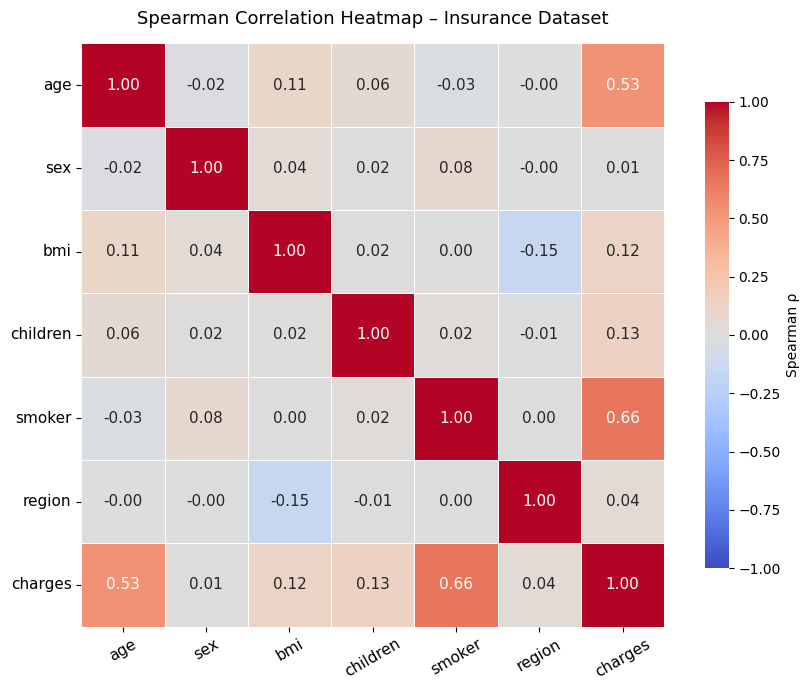

In [ ]:
import pandas as pd
from scipy.stats import spearmanr


# Encode categoricals ordinally so Spearman rank correlation is meaningful
df_encoded = df.copy()
df_encoded["sex"]    = df_encoded["sex"].map({"female": 0, "male": 1})
df_encoded["smoker"] = df_encoded["smoker"].map({"no": 0, "yes": 1})
df_encoded["region"] = df_encoded["region"].map(
    {"southwest": 0, "southeast": 1, "northwest": 2, "northeast": 3}
)

cols = ["age", "sex", "bmi", "children", "smoker", "region", "charges"]

# Compute full Spearman correlation matrix
n = len(cols)
rho_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)
p_matrix   = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        rho, p = spearmanr(df_encoded[c1], df_encoded[c2])
        rho_matrix.loc[c1, c2] = rho
        p_matrix.loc[c1, c2]   = p

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    rho_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 11},
    square=True,
    ax=ax,
    cbar_kws={"label": "Spearman ρ", "shrink": 0.8},
)

ax.set_title("Spearman Correlation Heatmap – Insurance Dataset", fontsize=13,
pad=14)
ax.tick_params(axis="x", rotation=30, labelsize=11)
ax.tick_params(axis="y", rotation=0,  labelsize=11)

plt.tight_layout()
plt.savefig("spearman_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Exploratory Data Analysis

In [ ]:
# identify categorical and numerical variables
categorical_vars = ['sex', 'smoker', 'region']
numerical_vars = ['age', 'bmi', 'children', 'charges']

print("Categorical variables:", categorical_vars)
print("Numerical variables:", numerical_vars)
print("\nData types:")
print(df.dtypes)

Categorical variables: ['sex', 'smoker', 'region']
Numerical variables: ['age', 'bmi', 'children', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


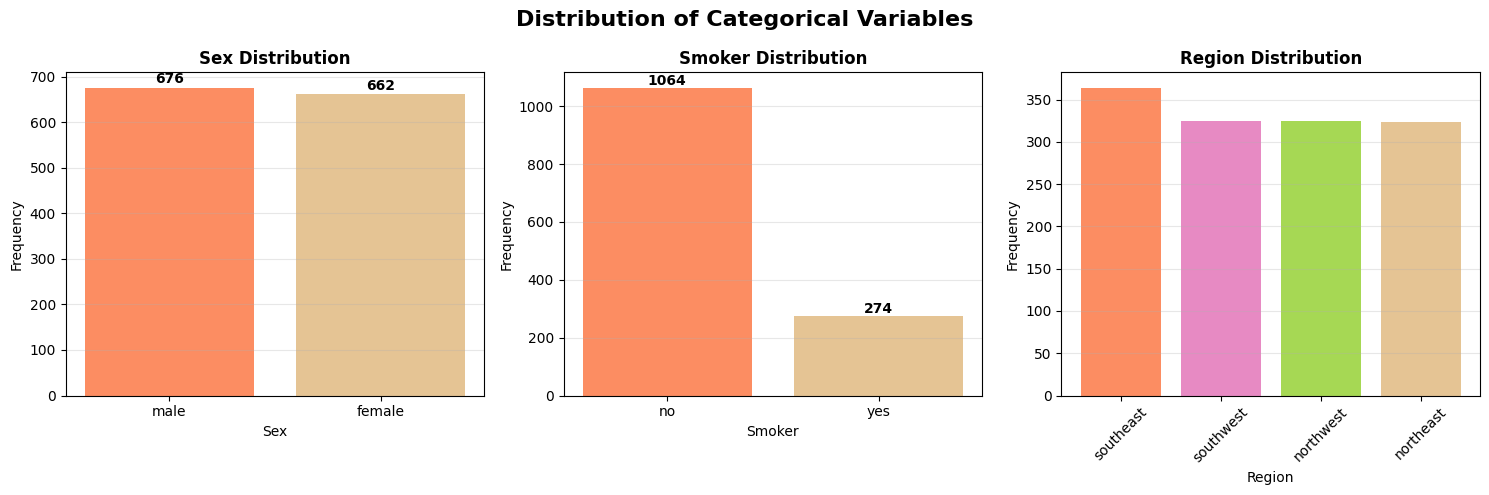

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold')

cmap = plt.cm.Set2

sex_counts = df['sex'].value_counts()
colors = cmap(np.linspace(0.2, 0.8, len(sex_counts)))

axes[0].bar(sex_counts.index, sex_counts.values, color=colors)
axes[0].set_title('Sex Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

smoker_counts = df['smoker'].value_counts()
colors = cmap(np.linspace(0.2, 0.8, len(smoker_counts)))

axes[1].bar(smoker_counts.index, smoker_counts.values, color=colors)
axes[1].set_title('Smoker Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(smoker_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

region_counts = df['region'].value_counts()
colors = cmap(np.linspace(0.2, 0.8, len(region_counts)))

axes[2].bar(region_counts.index, region_counts.values, color=colors)
axes[2].set_title('Region Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Frequency')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1439/410605557.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1439/410605557.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1439/410605557.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


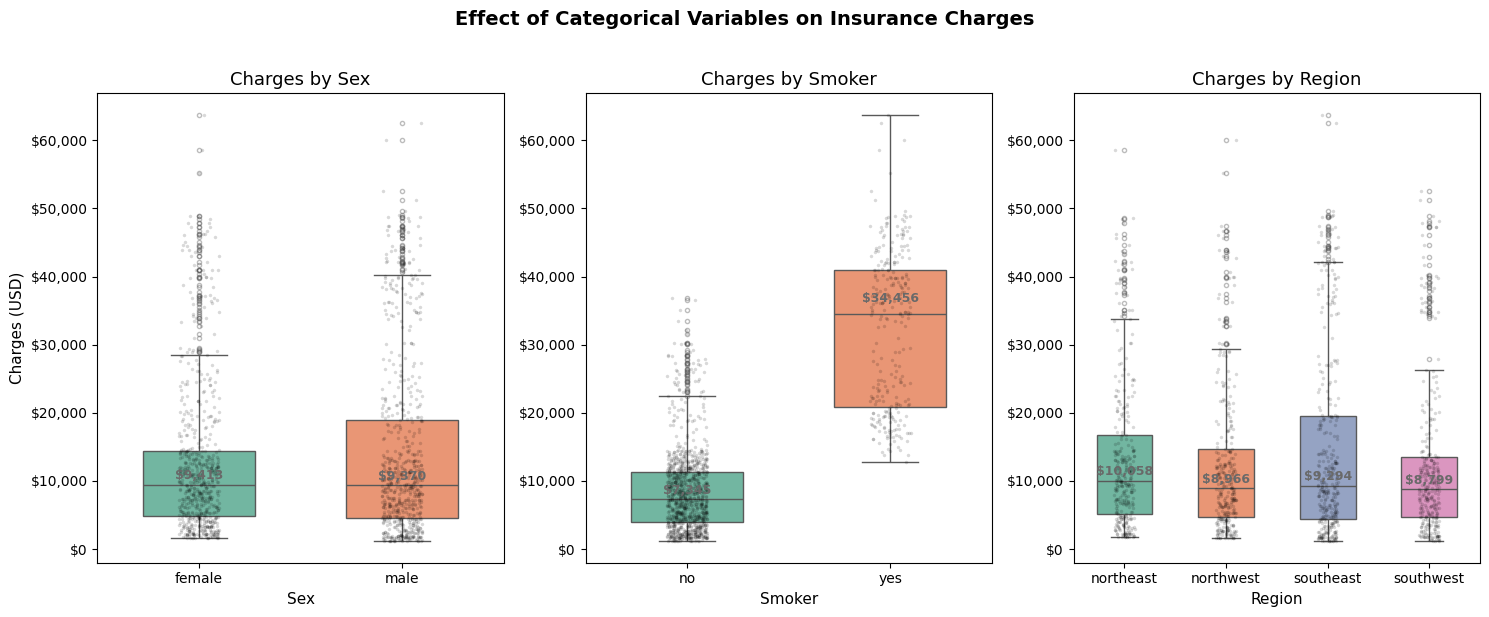

In [ ]:
  cat_vars = ["sex", "smoker", "region"]
  palette  = "Set2"

  fig, axes = plt.subplots(1, 3, figsize=(15, 6))

  for ax, var in zip(axes, cat_vars):
      order = sorted(df[var].unique())

      # Boxplot
      sns.boxplot(
          data=df,
          x=var,
          y="charges",
          order=order,
          palette=palette,
          width=0.55,
          flierprops=dict(marker="o", markersize=3, alpha=0.4),
          ax=ax,
      )

      # Overlay individual data points for context
      sns.stripplot(
          data=df,
          x=var,
          y="charges",
          order=order,
          color="black",
          alpha=0.15,
          size=2.5,
          jitter=True,
          ax=ax,
      )

      # Annotate median values above each box
      medians = df.groupby(var)["charges"].median()
      for i, cat in enumerate(order):
          ax.text(
              i, medians[cat] * 1.04,
              f"${medians[cat]:,.0f}",
              ha="center", va="bottom",
              fontsize=9, color="dimgray", fontweight="bold"
          )

      ax.set_title(f"Charges by {var.capitalize()}", fontsize=13)
      ax.set_xlabel(var.capitalize(), fontsize=11)
      ax.set_ylabel("Charges (USD)" if ax == axes[0] else "", fontsize=11)
      ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
      ax.tick_params(axis="x", labelsize=10)

  fig.suptitle(
      "Effect of Categorical Variables on Insurance Charges",
      fontsize=14, y=1.02, fontweight="bold"
  )
  plt.tight_layout()
  plt.savefig("boxplots_charges.png", dpi=150, bbox_inches="tight")
  plt.show()

Sex: This is well balanced. Male and female counts are almost equal.

Smoker: This is clearly imbalanced. Most individuals are non-smokers, with smokers making up a much smaller portion of the dataset.

Region: Fairly balanced across all four regions. No large difference between region counts.

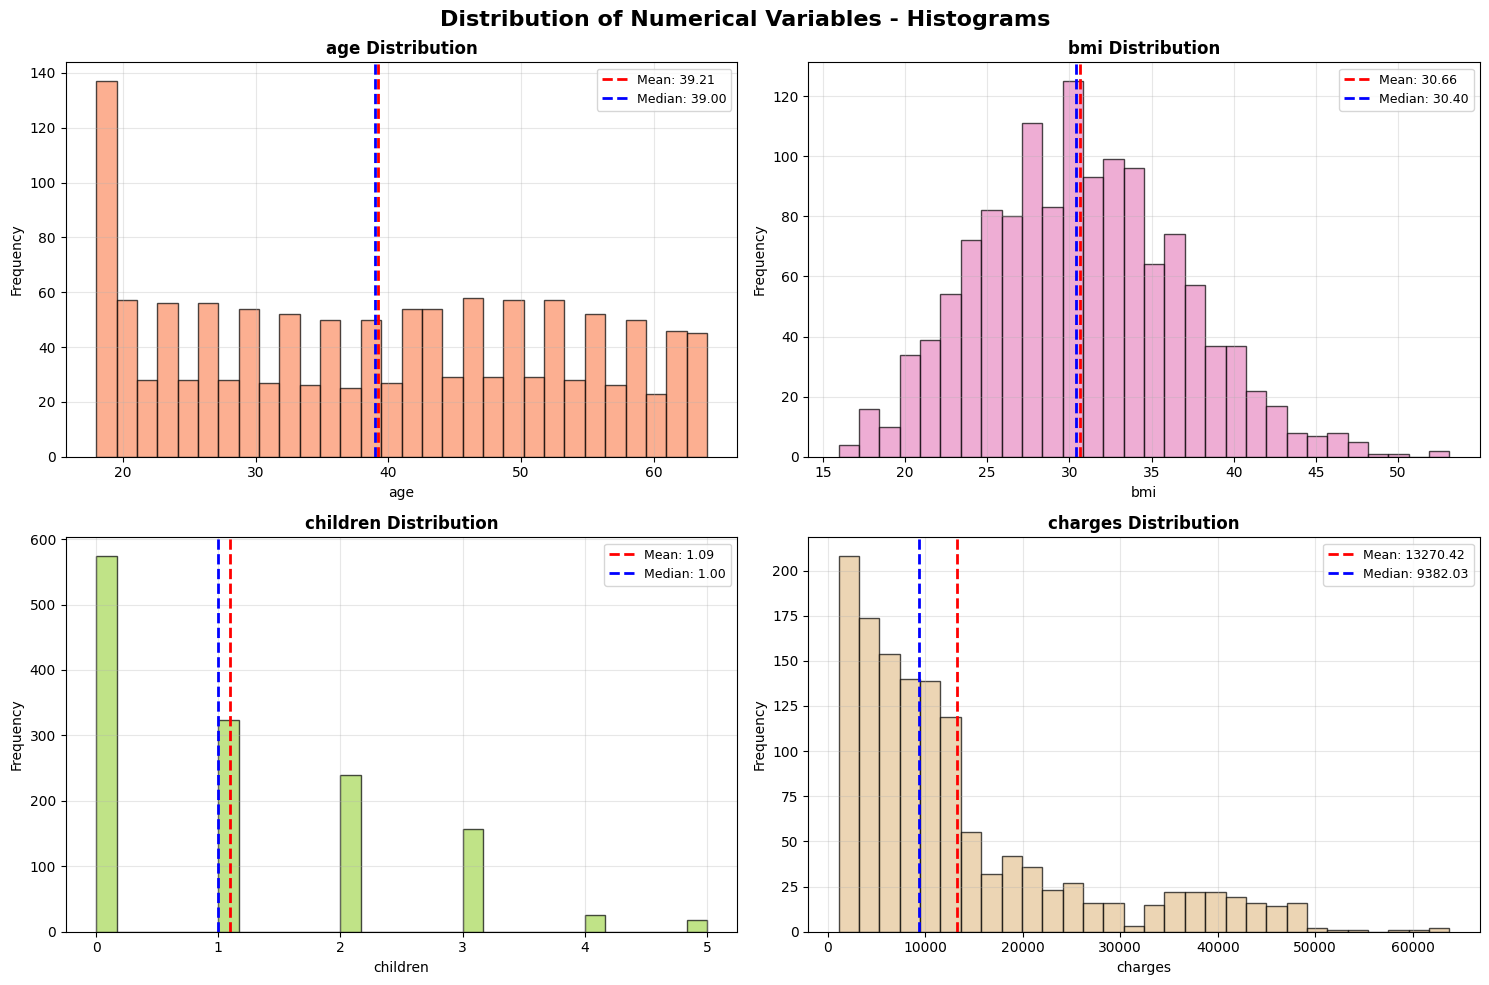

In [ ]:
# create histograms for numerical variables
# calculate grid size based on number of variables
n_vars = len(numerical_vars)
n_cols = 2
n_rows = (n_vars + n_cols - 1) // n_cols  # round up division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
fig.suptitle('Distribution of Numerical Variables - Histograms', fontsize=16, fontweight='bold')

# flatten axes for easier iteration
if n_rows == 1:
    axes_flat = axes if isinstance(axes, np.ndarray) else [axes]
else:
    axes_flat = axes.flatten()

colors = plt.cm.Set2(np.linspace(0.2, 0.8, n_vars))

for idx, var in enumerate(numerical_vars):
    ax = axes_flat[idx]

    ax.hist(
        df[var].dropna(),
        bins=30,
        edgecolor='black',
        alpha=0.7,
        color=colors[idx]
    )

    ax.set_title(f'{var} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

    # add mean and median lines
    mean_val = df[var].mean()
    median_val = df[var].median()

    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='blue', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')

    ax.legend(fontsize=9)

# hide unused subplots
for idx in range(n_vars, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

Age: This is pretty much uniform across the range. Mean and median are very close, so it’s balanced with no strong skew or clear outliers.

BMI: Looks bell-shaped with a slight right skew. Most values cluster around 25–35. A few high BMI values may be outliers.

Children: Discrete and right-skewed. Most people have 0–2 children. Higher values like 4 or 5 are rare and can be considered outliers.

Charges: Strongly right-skewed. Most observations are at lower costs, but there are some very large values. Mean is much higher than the median, which indicates clear outliers on the high end.

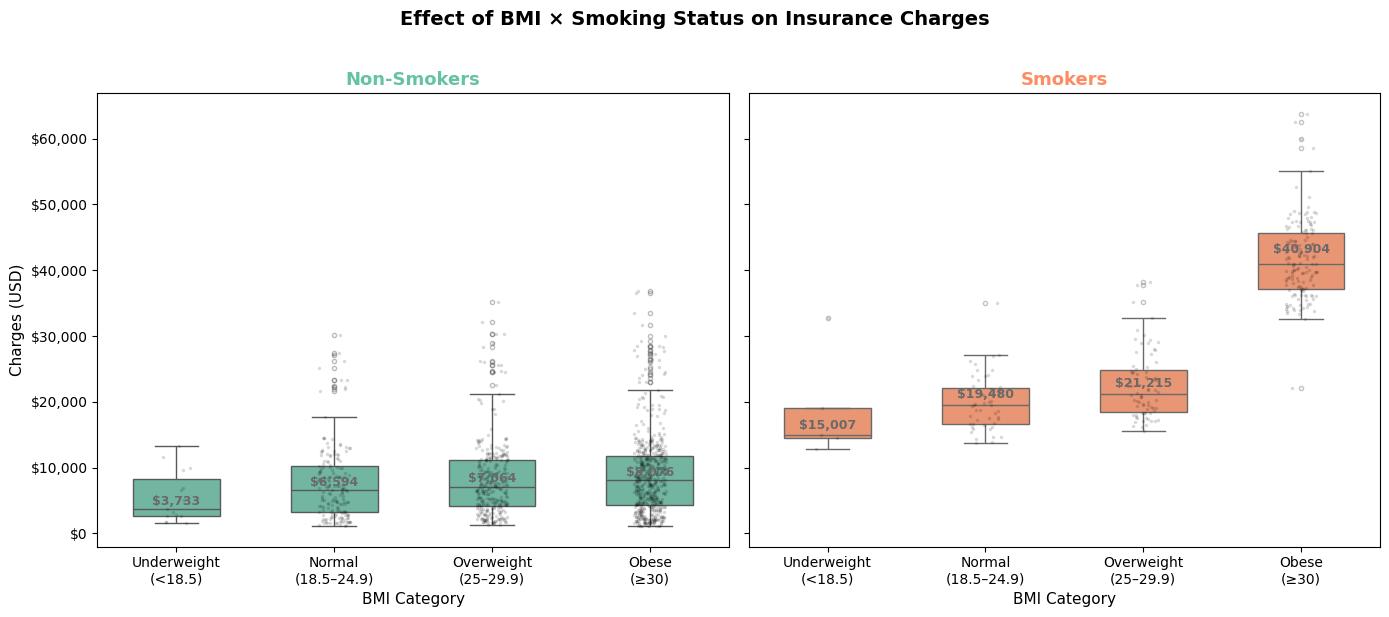

In [ ]:
# Bin BMI into standard WHO categories
bmi_bins   = [0, 18.5, 25, 30, float("inf")]
bmi_labels = ["Underweight\n(<18.5)", "Normal\n(18.5–24.9)",
              "Overweight\n(25–29.9)", "Obese\n(≥30)"]

df["bmi_category"] = pd.cut(df["bmi"], bins=bmi_bins, labels=bmi_labels, right=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

smoker_map = {"no": "Non-Smokers", "yes": "Smokers"}
order = bmi_labels

# Set2 palette
set2 = sns.color_palette("Set2")

palette_map = {
    "no": set2[0],   # teal
    "yes": set2[1]   # orange
}

for ax, (smoker_val, label) in zip(axes, smoker_map.items()):
    subset = df[df["smoker"] == smoker_val]

    sns.boxplot(
        data=subset,
        x="bmi_category",
        y="charges",
        order=order,
        color=palette_map[smoker_val],
        width=0.55,
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        ax=ax
    )

    sns.stripplot(
        data=subset,
        x="bmi_category",
        y="charges",
        order=order,
        color="black",
        alpha=0.15,
        size=2.5,
        jitter=True,
        ax=ax
    )

    medians = subset.groupby("bmi_category", observed=True)["charges"].median()

    for i, cat in enumerate(order):
        if cat in medians.index:
            ax.text(
                i, medians[cat] * 1.03,
                f"${medians[cat]:,.0f}",
                ha="center", va="bottom",
                fontsize=9, color="dimgray", fontweight="bold"
            )

    ax.set_title(label, fontsize=13, fontweight="bold", color=palette_map[smoker_val])
    ax.set_xlabel("BMI Category", fontsize=11)
    ax.set_ylabel("Charges (USD)" if ax == axes[0] else "", fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

fig.suptitle(
    "Effect of BMI × Smoking Status on Insurance Charges",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("bmi_smoking_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

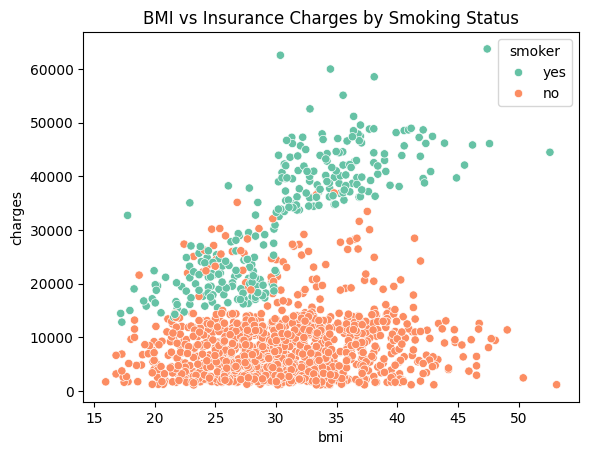

In [ ]:
sns.scatterplot(
    x="bmi",
    y="charges",
    hue="smoker",
    data=df,
    palette="Set2"
)
plt.title("BMI vs Insurance Charges by Smoking Status")
plt.show()

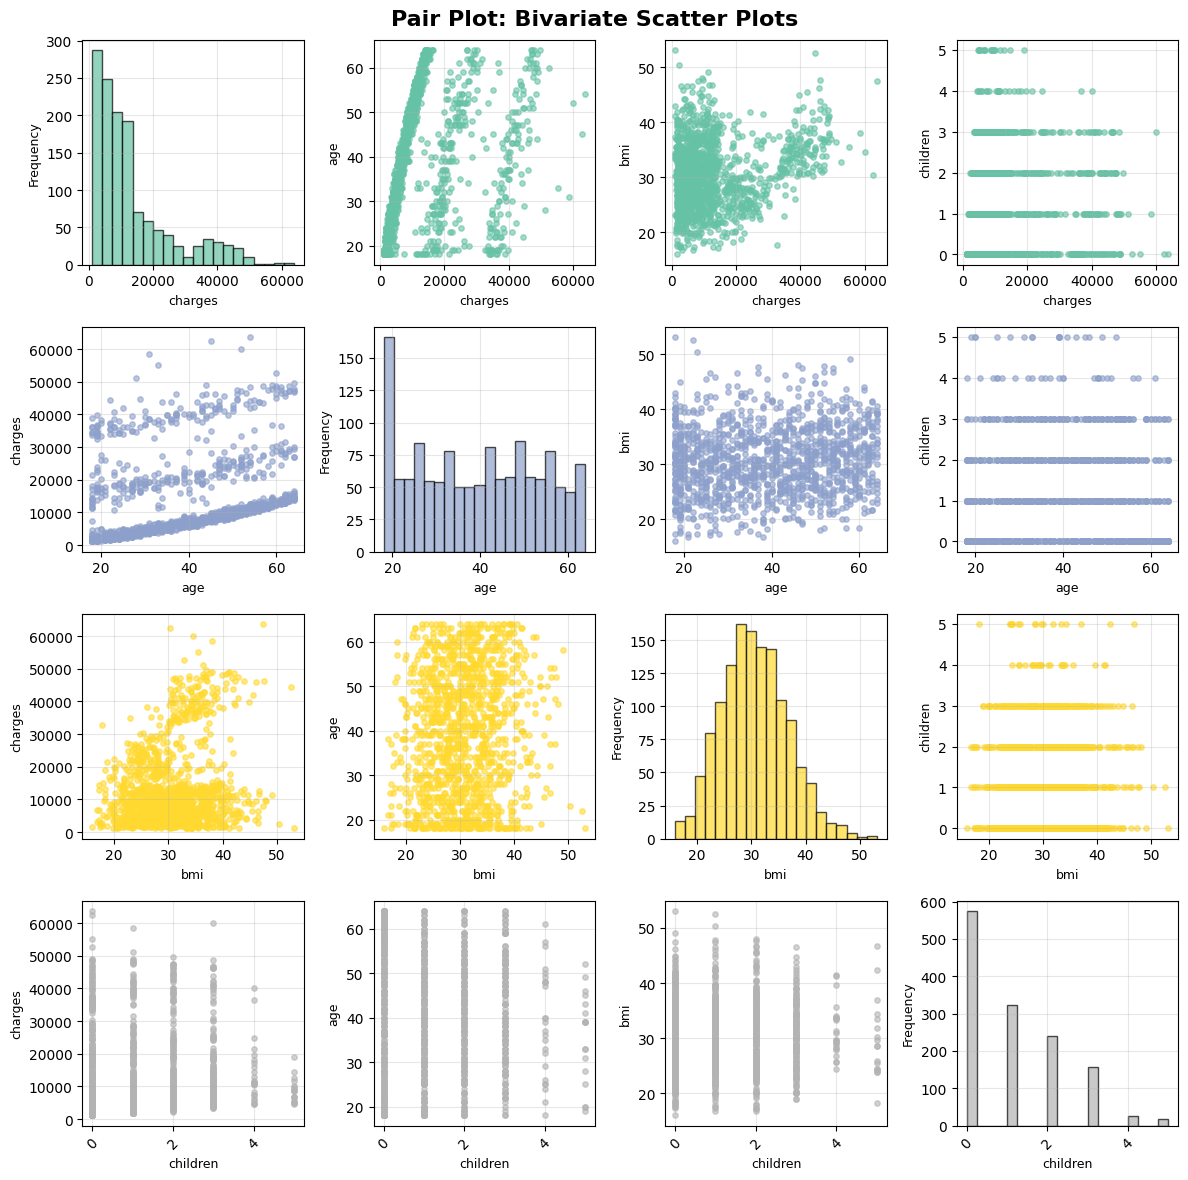

In [ ]:
# response variable goes first (upper left corner), provided by LLM
import matplotlib.pyplot as plt
import numpy as np

response_var = ['charges']
predictor_vars = ['age', 'bmi', 'children']
plot_vars = response_var + predictor_vars

fig, axes = plt.subplots(len(plot_vars), len(plot_vars), figsize=(12, 12))
fig.suptitle('Pair Plot: Bivariate Scatter Plots', fontsize=16, fontweight='bold')

cmap = plt.cm.Set2
colors = cmap(np.linspace(0, 1, len(plot_vars)))

for i, var1 in enumerate(plot_vars):
    for j, var2 in enumerate(plot_vars):
        ax = axes[i, j]

        if i == j:
            ax.hist(
                df[var1].dropna(),
                bins=20,
                edgecolor='black',
                alpha=0.7,
                color=colors[i]
            )
            ax.set_xlabel(var1, fontsize=9)
            ax.set_ylabel('Frequency', fontsize=9)

        else:
            ax.scatter(
                df[var1],
                df[var2],
                alpha=0.6,
                s=15,
                color=colors[i]
            )
            ax.set_xlabel(var1, fontsize=9)
            ax.set_ylabel(var2, fontsize=9)

        ax.grid(alpha=0.3)

        if i == len(plot_vars) - 1:
            ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

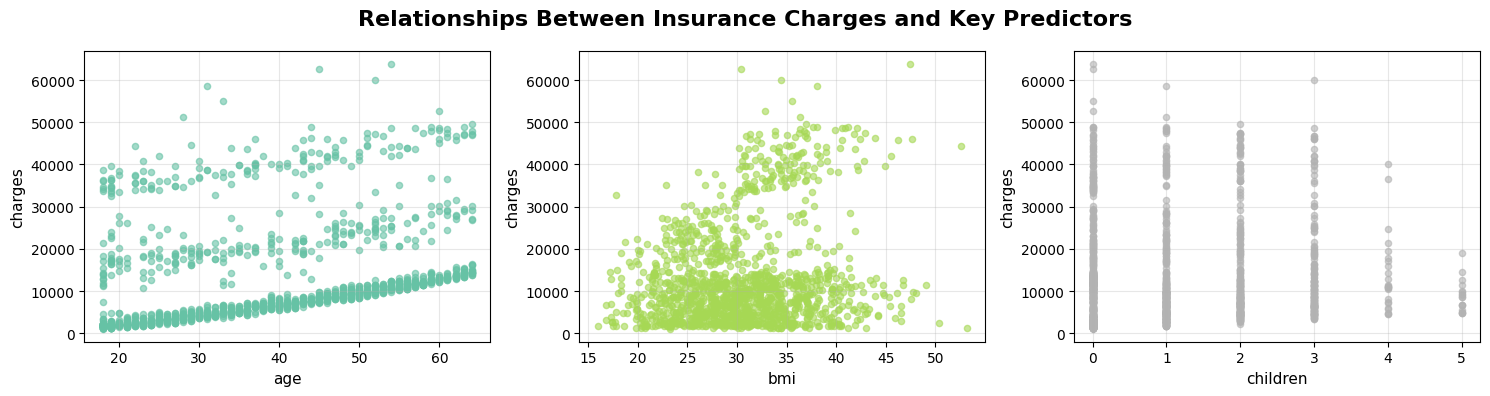

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

response_var = 'charges'
predictor_vars = ['age', 'bmi', 'children']

fig, axes = plt.subplots(1, len(predictor_vars), figsize=(15,4))
fig.suptitle('Relationships Between Insurance Charges and Key Predictors', fontsize=16, fontweight='bold')

cmap = plt.cm.Set2
colors = cmap(np.linspace(0,1,len(predictor_vars)))

for i, var in enumerate(predictor_vars):

    axes[i].scatter(
        df[var],
        df[response_var],
        alpha=0.6,
        s=20,
        color=colors[i]
    )

    axes[i].set_xlabel(var, fontsize=11)
    axes[i].set_ylabel("charges", fontsize=11)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Charges: Right-skewed with several extreme high values, showing that there are clear outliers. Variability increases as charges increase.

Age vs. Charges: Strong positive nonlinear relationship. Charges rise rapidly at higher ages which may indicate it is not linear.

BMI vs. Charges: Weak linear association. Most high charges occur at higher BMI values, but the pattern is pretty scattered, suggesting other factors and not a strong correlation.

Children: Discrete and weakly related to the other variables. No strong trend with charges, age, or BMI.

Predictor–predictor relationships:

- Age and BMI have a low correlation.

- Age and children have a mild association.

- BMI and children appears uncorrelated.

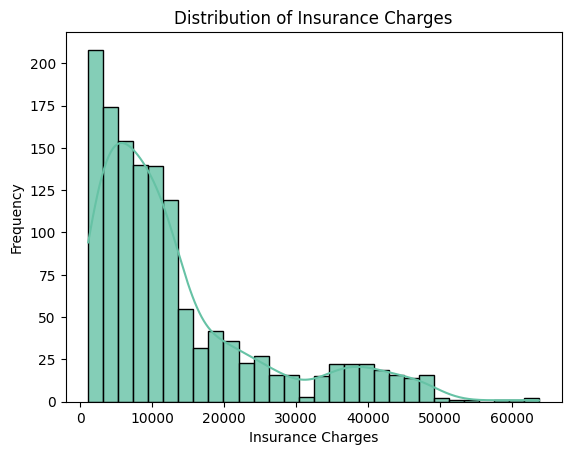

In [ ]:
sns.histplot(
    df["charges"],
    kde=True,
    color=sns.color_palette("Set2")[0],
    edgecolor="black",
    alpha=0.8
)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")

plt.show()

Our primary model is a multiple linear regression of insurance charges on age, BMI, number of children, sex, smoking status, and region. Because charges are strongly right-skewed and residual plots suggest heteroskedasticity, we supplement the OLS analysis with bootstrap standard errors to assess the stability of coefficient inference.

In [ ]:
model = smf.ols(
    formula="charges ~ age + bmi + children + sex + smoker + region",
    data=df
).fit()

display(HTML(model.summary().as_html()))

std_errors = model.bse
print("\nStandard Errors:")
print(std_errors)


Standard Errors:
Intercept              987.819175
sex[T.male]            332.945439
smoker[T.yes]          413.153355
region[T.northwest]    476.275786
region[T.southeast]    478.692209
region[T.southwest]    477.933024
age                     11.898849
bmi                     28.599470
children               137.804093
dtype: float64


In [ ]:


# Create clean regression table
ols_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "Std. Error": model.bse.values,
    "t-value": model.tvalues.values,
    "p-value": model.pvalues.values
})

ols_table["Variable"] = ols_table["Variable"].replace({
    "Intercept": "Intercept",
    "sex[T.male]": "Male",
    "smoker[T.yes]": "Smoker",
    "region[T.northwest]": "Region: Northwest",
    "region[T.southeast]": "Region: Southeast",
    "region[T.southwest]": "Region: Southwest",
    "age": "Age",
    "bmi": "BMI",
    "children": "Children"
})

# ---------------------------
# Round values for readability
# ---------------------------
ols_table = ols_table.round({
    "Coefficient": 2,
    "Std. Error": 2,
    "t-value": 2,
    "p-value": 3
})

# ---------------------------
# Display table
# ---------------------------
print("OLS Regression Summary Table")
display(ols_table)

# ---------------------------
# Print model fit stats
# ---------------------------
print("\nModel Fit Statistics")
print("R-squared:", round(model.rsquared, 3))
print("Adjusted R-squared:", round(model.rsquared_adj, 3))
print("Observations:", int(model.nobs))


OLS Regression Summary Table


,Variable,Coefficient,Std. Error,t-value,p-value
0,Intercept,-11938.54,987.82,-12.09,0.000
1,Male,-131.31,332.95,-0.39,0.693
2,Smoker,23848.53,413.15,57.72,0.000
3,Region: Northwest,-352.96,476.28,-0.74,0.459
4,Region: Southeast,-1035.02,478.69,-2.16,0.031
5,Region: Southwest,-960.05,477.93,-2.01,0.045
6,Age,256.86,11.90,21.59,0.000
7,BMI,339.19,28.60,11.86,0.000
8,Children,475.50,137.80,3.45,0.001



Model Fit Statistics
R-squared: 0.751
Adjusted R-squared: 0.749
Observations: 1338


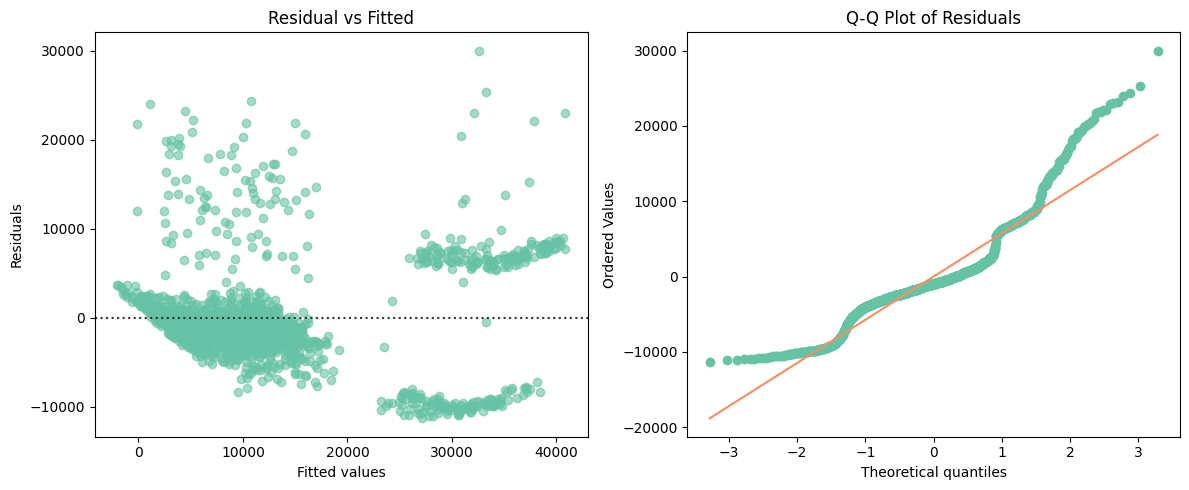

In [ ]:
# Residual vs fitted
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

set2 = sns.color_palette("Set2")

sns.residplot(
    x=model.fittedvalues,
    y=model.resid,
    ax=axes[0],
    scatter_kws={"color": set2[0], "alpha": 0.6},
    line_kws={"color": set2[1]}
)

axes[0].set_title("Residual vs Fitted")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

# Q-Q plot
stats.probplot(model.resid, dist="norm", plot=axes[1])

# recolor Q-Q plot points and line
axes[1].get_lines()[0].set_color(set2[0])  # points
axes[1].get_lines()[1].set_color(set2[1])  # reference line

axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [ ]:
# -----------------------------------
# Formal OLS Assumption Tests
# -----------------------------------

# Residuals and design matrix
residuals = model.resid
exog = model.model.exog

# Breusch-Pagan test
bp_lm_stat, bp_lm_p, bp_f_stat, bp_f_p = het_breuschpagan(residuals, exog)

# Shapiro-Wilk test
shapiro_stat, shapiro_p = shapiro(residuals)

# Durbin-Watson statistic
dw_stat = durbin_watson(residuals)

# Build clean table
assumption_tests = pd.DataFrame({
    "Test": [
        "Breusch-Pagan (LM)",
        "Breusch-Pagan (F)",
        "Shapiro-Wilk",
        "Durbin-Watson"
    ],
    "Statistic": [
        bp_lm_stat,
        bp_f_stat,
        shapiro_stat,
        dw_stat
    ],
    "p-value": [
        bp_lm_p,
        bp_f_p,
        shapiro_p,
        np.nan
    ],
    "Conclusion": [
        "Heteroskedasticity present" if bp_lm_p < 0.05 else "No heteroskedasticity detected",
        "Heteroskedasticity present" if bp_f_p < 0.05 else "No heteroskedasticity detected",
        "Residuals not normal" if shapiro_p < 0.05 else "Residuals approximately normal",
        "No autocorrelation concern" if 1.5 <= dw_stat <= 2.5 else "Possible autocorrelation"
    ]
})

# Optional: cleaner p-value formatting
def format_pval(x):
    if pd.isna(x):
        return ""
    elif x < 0.0001:
        return "<0.0001"
    else:
        return f"{x:.4f}"

assumption_tests_styled = (
    assumption_tests.style
    .format({
        "Statistic": "{:.4f}",
        "p-value": format_pval
    })
    .set_caption("Formal Regression Assumption Tests")
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt"
    })
    .set_table_styles([
        {"selector": "th",
         "props": [("text-align", "center"),
                   ("font-weight", "bold")]}
    ])
)

assumption_tests_styled

,Test,Statistic,p-value,Conclusion
0,Breusch-Pagan (LM),121.7436,<0.0001,Heteroskedasticity present
1,Breusch-Pagan (F),16.6286,<0.0001,Heteroskedasticity present
2,Shapiro-Wilk,0.8989,<0.0001,Residuals not normal
3,Durbin-Watson,2.0884,,No autocorrelation concern


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Variable"] = model.model.exog_names
vif_df["VIF"] = [
    variance_inflation_factor(model.model.exog, i)
    for i in range(model.model.exog.shape[1])
]

vif_df = vif_df.round(3)
vif_clean = vif_df.copy()
vif_clean["Variable"] = (
    vif_clean["Variable"]
    .str.replace("smoker[T.yes", "Smoker")
    .str.replace("sex[T.male", "Male")
    .str.replace("region[T.northwest]", "Region: Northwest")
    .str.replace("region[T.southeast]", "Region: Southeast")
    .str.replace("region[T.southwest]", "Region: Southwest")
)

vif_clean.style \
    .format({"VIF": "{:.3f}"}) \
    .background_gradient(cmap="Blues", subset=["VIF"]) \
    .set_caption("Variance Inflation Factors (Multicollinearity Check)") \
    .set_properties(**{
        "text-align": "center",
        "font-size": "12pt"
    }) \
    .set_table_styles([
        {"selector": "th",
         "props": [("text-align", "center"),
                   ("font-weight", "bold")]}
    ])

,Variable,VIF
0,Intercept,35.527
1,Male],1.009
2,Smoker],1.012
3,Region: Northwest,1.519
4,Region: Southeast,1.652
5,Region: Southwest,1.529
6,age,1.017
7,bmi,1.107
8,children,1.004


In [ ]:
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Gamma
from statsmodels.genmod.families.links import log as log_link
from IPython.display import display, HTML

# Use the same design matrix as the OLS model
X = model.model.exog
y = model.model.endog

gamma_glm = GLM(
    y,
    X,
    family=Gamma(link=log_link()),
).fit()

display(HTML(gamma_glm.summary(xname=model.model.exog_names).as_html()))
# Compare AIC
print("\nModel comparison (AIC):")
print(f"  OLS:       {model.aic:.1f}")
print(f"  Gamma GLM: {gamma_glm.aic:.1f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(



Model comparison (AIC):
  OLS:       27113.5
  Gamma GLM: 26632.8


In [ ]:
# Interaction model: BMI × smoker
model_bmi_smoker = smf.ols(
    formula="charges ~ age + bmi + children + sex + smoker + region + bmi:smoker",
    data=df
).fit()
display(HTML(model_bmi_smoker.summary().as_html()))

In [ ]:
import pandas as pd

# ---------------------------
# Create regression table
# ---------------------------
interaction_table = pd.DataFrame({
    "Variable": model_bmi_smoker.params.index,
    "Coefficient": model_bmi_smoker.params.values,
    "Std. Error": model_bmi_smoker.bse.values,
    "t-value": model_bmi_smoker.tvalues.values,
    "p-value": model_bmi_smoker.pvalues.values
})

# ---------------------------
# Clean variable names
# ---------------------------
interaction_table["Variable"] = interaction_table["Variable"].replace({
    "Intercept": "Intercept",
    "sex[T.male]": "Male",
    "smoker[T.yes]": "Smoker",
    "region[T.northwest]": "Region: Northwest",
    "region[T.southeast]": "Region: Southeast",
    "region[T.southwest]": "Region: Southwest",
    "age": "Age",
    "bmi": "BMI",
    "children": "Children",
    "bmi:smoker[T.yes]": "BMI × Smoker"
})

# ---------------------------
# Round values
# ---------------------------
interaction_table = interaction_table.round({
    "Coefficient": 2,
    "Std. Error": 2,
    "t-value": 2,
    "p-value": 3
})

# ---------------------------
# Display table
# ---------------------------
print("BMI × Smoker Interaction Model Summary")
display(interaction_table)

# ---------------------------
# Model fit stats
# ---------------------------
print("\nModel Fit Statistics")
print("R-squared:", round(model_bmi_smoker.rsquared, 3))
print("Adjusted R-squared:", round(model_bmi_smoker.rsquared_adj, 3))
print("Observations:", int(model_bmi_smoker.nobs))


BMI × Smoker Interaction Model Summary


,Variable,Coefficient,Std. Error,t-value,p-value
0,Intercept,-2223.45,865.61,-2.57,0.010
1,Male,-500.15,266.52,-1.88,0.061
2,Smoker,-20415.61,1648.28,-12.39,0.000
3,Region: Northwest,-585.48,380.86,-1.54,0.124
4,Region: Southeast,-1210.13,382.75,-3.16,0.002
5,Region: Southwest,-1231.11,382.22,-3.22,0.001
6,Age,263.62,9.52,27.70,0.000
7,BMI,23.53,25.60,0.92,0.358
8,BMI × Smoker,1443.10,52.65,27.41,0.000
9,Children,516.40,110.18,4.69,0.000



Model Fit Statistics
R-squared: 0.841
Adjusted R-squared: 0.84
Observations: 1338


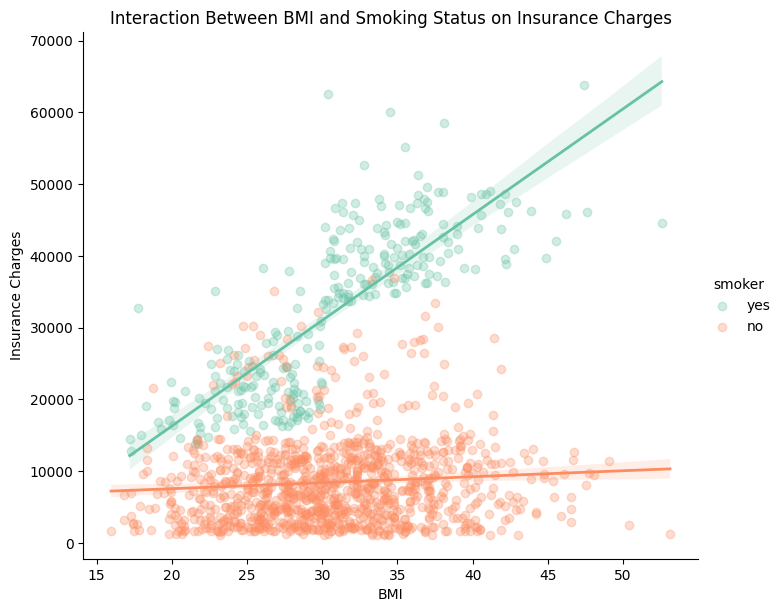

In [ ]:
sns.lmplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker",
    palette="Set2",
    scatter_kws={"alpha":0.3},
    line_kws={"linewidth":2},
    height=6,
    aspect=1.2
)

plt.title("Interaction Between BMI and Smoking Status on Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

The scatter plot of BMI and insurance charges reveals distinct patterns between smokers and non-smokers. Smokers exhibit substantially higher charges across nearly all BMI levels and form a clear high-cost cluster in the upper portion of the distribution. Additionally, the slope of the regression line for smokers is noticeably steeper, indicating that increases in BMI are associated with larger increases in insurance costs among smokers compared to non-smokers. These patterns suggest that smoking both increases baseline medical costs and amplifies the effect of BMI on insurance expenditures.

In [ ]:
# Interaction model: Age × Smoker
model_age_smoker = smf.ols(
    formula="charges ~ age + bmi + children + sex + smoker + region + age:smoker",
    data=df
).fit()

display(HTML(model_age_smoker.summary().as_html()))

In [ ]:

# ---------------------------
# Create regression table
# ---------------------------
age_smoker_table = pd.DataFrame({
    "Variable": model_age_smoker.params.index,
    "Coefficient": model_age_smoker.params.values,
    "Std. Error": model_age_smoker.bse.values,
    "t-value": model_age_smoker.tvalues.values,
    "p-value": model_age_smoker.pvalues.values
})

# ---------------------------
# Clean variable names
# ---------------------------
age_smoker_table["Variable"] = age_smoker_table["Variable"].replace({
    "Intercept": "Intercept",
    "sex[T.male]": "Male",
    "smoker[T.yes]": "Smoker",
    "region[T.northwest]": "Region: Northwest",
    "region[T.southeast]": "Region: Southeast",
    "region[T.southwest]": "Region: Southwest",
    "age": "Age",
    "bmi": "BMI",
    "children": "Children",
    "age:smoker[T.yes]": "Age × Smoker"
})

# ---------------------------
# Round numbers
# ---------------------------
age_smoker_table = age_smoker_table.round({
    "Coefficient": 2,
    "Std. Error": 2,
    "t-value": 2,
    "p-value": 3
})

# ---------------------------
# Display table
# ---------------------------
print("Age × Smoker Interaction Model Summary")
display(age_smoker_table)

# ---------------------------
# Model fit statistics
# ---------------------------
print("\nModel Fit Statistics")
print("R-squared:", round(model_age_smoker.rsquared, 3))
print("Adjusted R-squared:", round(model_age_smoker.rsquared_adj, 3))
print("Observations:", int(model_age_smoker.nobs))

Age × Smoker Interaction Model Summary


,Variable,Coefficient,Std. Error,t-value,p-value
0,Intercept,-11612.13,1010.15,-11.50,0.000
1,Male,-135.16,332.79,-0.41,0.685
2,Smoker,22105.00,1213.13,18.22,0.000
3,Region: Northwest,-362.54,476.08,-0.76,0.446
4,Region: Southeast,-1060.06,478.73,-2.21,0.027
5,Region: Southwest,-943.31,477.82,-1.97,0.049
6,Age,247.73,13.31,18.62,0.000
7,Age × Smoker,45.13,29.53,1.53,0.127
8,BMI,340.62,28.60,11.91,0.000
9,Children,471.41,137.76,3.42,0.001



Model Fit Statistics
R-squared: 0.751
Adjusted R-squared: 0.75
Observations: 1338


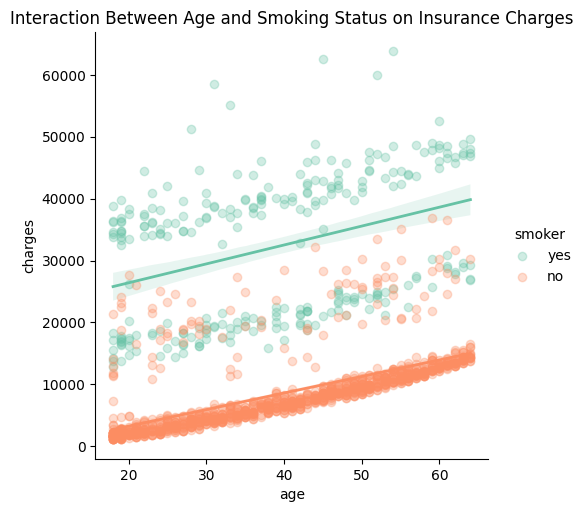

In [ ]:
sns.lmplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker",
    palette="Set2",
    scatter_kws={"alpha":0.3},
    line_kws={"linewidth":2}
)

plt.title("Interaction Between Age and Smoking Status on Insurance Charges")
plt.show()

In [ ]:
# Interaction model: Age × BMI
model_age_bmi = smf.ols(
    formula="charges ~ age + bmi + children + sex + smoker + region + age:bmi",
    data=df
).fit()

display(HTML(model_age_bmi.summary().as_html()))

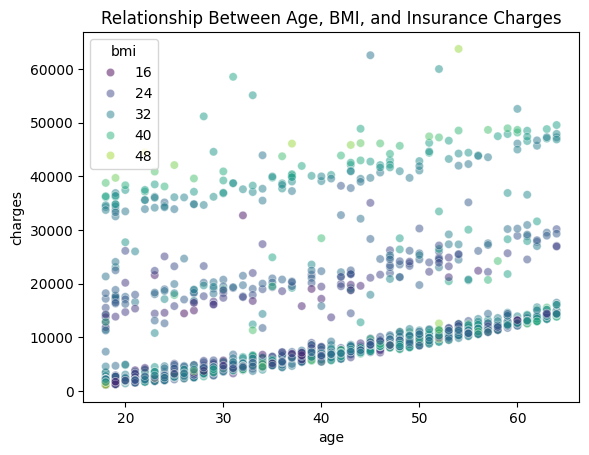

In [ ]:
sns.scatterplot(data=df, x="age", y="charges", hue="bmi", palette="viridis", alpha=0.5)
plt.title("Relationship Between Age, BMI, and Insurance Charges")
plt.show()

In [ ]:
# -----------------------------------
# Helper function for model summaries
# -----------------------------------
def get_model_summary_row(name, fitted_model):
    resid = fitted_model.resid
    exog = fitted_model.model.exog

    # Breusch-Pagan
    bp = het_breuschpagan(resid, exog)
    bp_pvalue = bp[1]

    # Shapiro-Wilk
    shapiro_stat, shapiro_p = shapiro(resid)

    # Durbin-Watson
    dw = durbin_watson(resid)

    return {
        "Model": name,
        "R²": fitted_model.rsquared,
        "Adj R²": fitted_model.rsquared_adj,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic,
        "RMSE": np.sqrt(np.mean(resid**2)),
        "BP p-value": bp_pvalue,
        "Shapiro p-value": shapiro_p,
        "Durbin-Watson": dw
    }

# -----------------------------------
# Build comparison table
# -----------------------------------
model_comparison = pd.DataFrame([
    get_model_summary_row("Base OLS", model),
    get_model_summary_row("BMI × Smoker", model_bmi_smoker),
    get_model_summary_row("Age × Smoker", model_age_smoker),
    get_model_summary_row("Age × BMI", model_age_bmi),
])

model_comparison = model_comparison.round({
    "R²": 3,
    "Adj R²": 3,
    "AIC": 1,
    "BIC": 1,
    "RMSE": 2,
    "BP p-value": 4,
    "Shapiro p-value": 4,
    "Durbin-Watson": 3
})

print("Model Comparison Table")
display(model_comparison.sort_values(by="Adj R²", ascending=False).reset_index(drop=True))

Model Comparison Table


,Model,R²,Adj R²,AIC,BIC,RMSE,BP p-value,Shapiro p-value,Durbin-Watson
0,BMI × Smoker,0.841,0.840,26515.6,26567.6,4828.28,0.3427,0.0,2.069
1,Age × Smoker,0.751,0.750,27113.2,27165.1,6036.37,0.0000,0.0,2.093
2,Base OLS,0.751,0.749,27113.5,27160.3,6041.68,0.0000,0.0,2.088
3,Age × BMI,0.751,0.749,27115.5,27167.5,6041.65,0.0000,0.0,2.088


In [ ]:
# Binary outcome: above-median charges
df["high_cost"] = (df["charges"] > df["charges"].median()).astype(int)

# Logistic regression
logit_model = smf.logit(
    formula="high_cost ~ age + bmi + children + sex + smoker + region",
    data=df
).fit()
display(HTML(logit_model.summary().as_html()))

# Classification results
y_pred = (logit_model.predict(df) >= 0.5).astype(int)
y_true = df["high_cost"]
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred))
print(f"\nAccuracy: {accuracy_score(y_true, y_pred):.4f}")

         Current function value: 0.289034
         Iterations: 35


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Confusion Matrix:
[[613  56]
 [ 60 609]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       669
           1       0.92      0.91      0.91       669

    accuracy                           0.91      1338
   macro avg       0.91      0.91      0.91      1338
weighted avg       0.91      0.91      0.91      1338


Accuracy: 0.9133


In [ ]:
# Bootstrap for OLS coefficients
np.random.seed(42)
B = 1000
n = len(df)
formula = "charges ~ age + bmi + children + sex + smoker + region"
boot_coefs = []

for _ in range(B):
    idx = np.random.choice(n, size=n, replace=True)
    df_boot = df.iloc[idx]
    m = smf.ols(formula, data=df_boot).fit()
    boot_coefs.append(m.params.values)

boot_coefs = np.array(boot_coefs)
boot_se = np.std(boot_coefs, axis=0)

# Compare OLS SE vs Bootstrap SE
compare = pd.DataFrame({
    "Coefficient": model.params.index,
    "OLS SE": model.bse.values,
    "Bootstrap SE": boot_se
})
print("SE Comparison (OLS vs Bootstrap):")
print(compare)

# Set2 palette
set2 = sns.color_palette("Set2")

# Coefficient distribution (e.g., smoker[T.yes])
smoker_idx = list(model.params.index).index("smoker[T.yes]") if "smoker[T.yes]" in model.params.index else 0

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    boot_coefs[:, smoker_idx],
    bins=30,
    edgecolor="black",
    alpha=0.8,
    color=set2[0]
)

ax.axvline(
    model.params.iloc[smoker_idx],
    color=set2[1],
    linestyle="--",
    linewidth=2,
    label="OLS estimate"
)

ax.set_xlabel("Bootstrap coefficient (smoker[T.yes])")
ax.set_ylabel("Frequency")
ax.set_title("Bootstrap Distribution of Smoker Coefficient")

ax.legend()
plt.show()

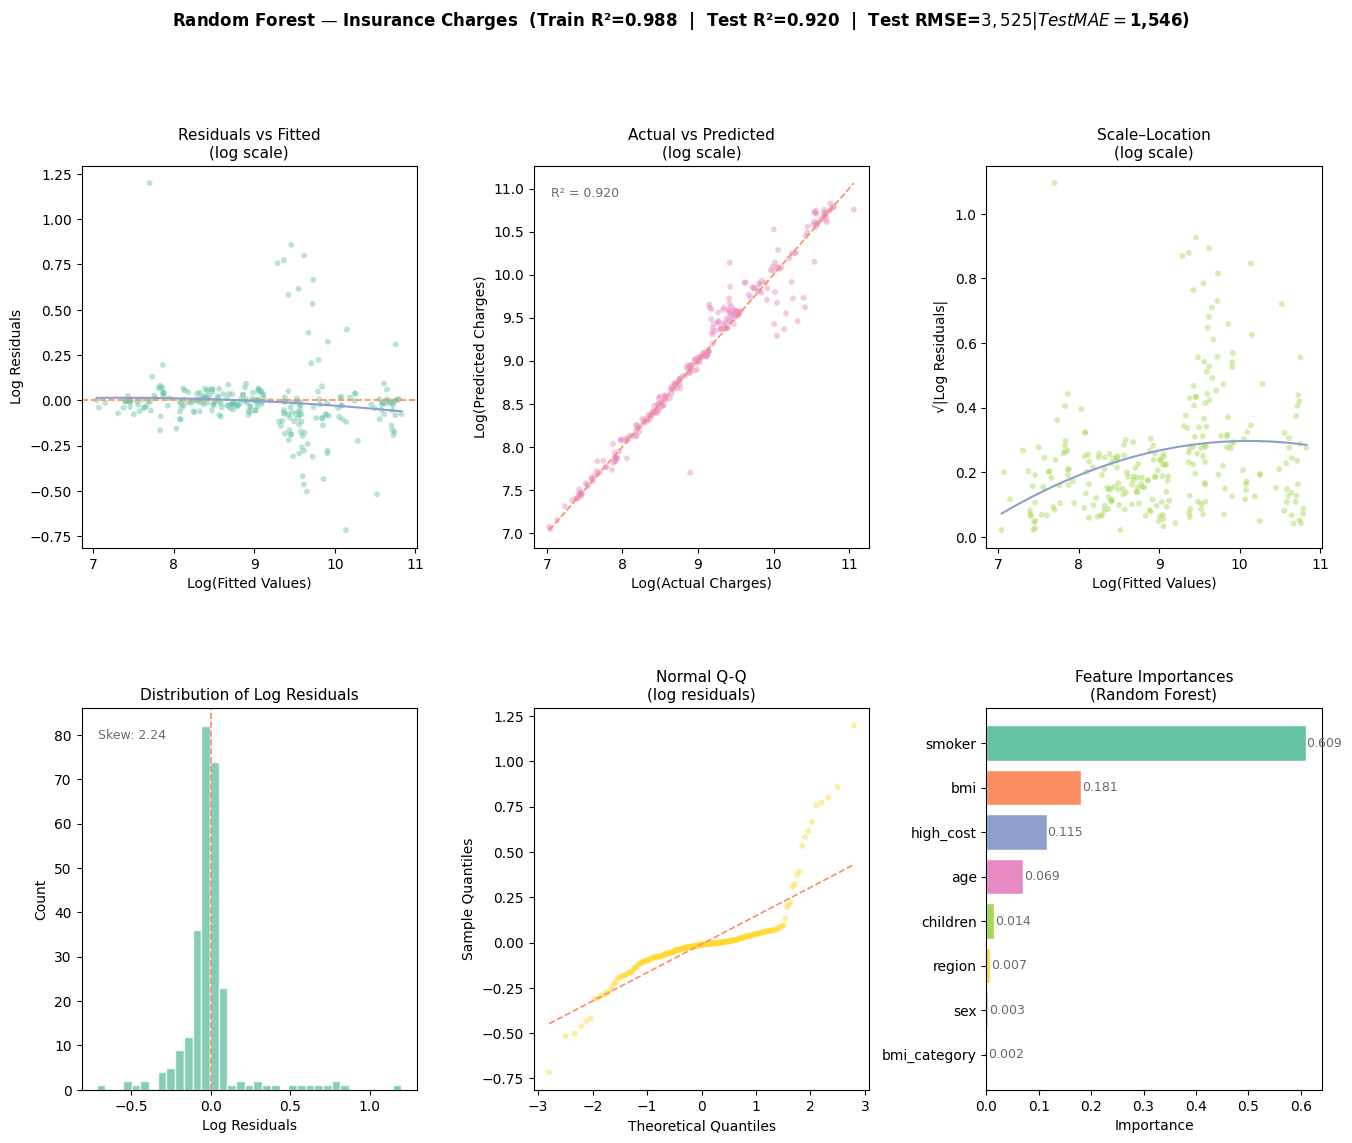

In [ ]:
# ── Encode categorical variables ───────────────────────────────────────────────
df_enc = df.copy()

# encode every object/category column except the response
cat_cols = df_enc.drop(columns="charges").select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

X = df_enc.drop(columns="charges")
y = df_enc["charges"]

# ── Train / test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Random Forest ──────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test  = rf.predict(X_test)

# ── Metrics ────────────────────────────────────────────────────────────────────
metrics = {
    "Train R²":  r2_score(y_train, y_pred_train),
    "Test R²":   r2_score(y_test,  y_pred_test),
    "Test RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    "Test MAE":  mean_absolute_error(y_test, y_pred_test),
}

# ── Feature importances ────────────────────────────────────────────────────────
feat_imp = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# ── Log-scale residuals ────────────────────────────────────────────────────────
log_pred   = np.log(y_pred_test)
log_actual = np.log(y_test)
log_resid  = log_actual - log_pred

# ── Set2 palette ───────────────────────────────────────────────────────────────
set2 = sns.color_palette("Set2")

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
xline = np.linspace(log_pred.min(), log_pred.max(), 200)

# ── Plot 1: Residuals vs Fitted ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(log_pred, log_resid, alpha=0.45, s=18, color=set2[0], edgecolors="none")
ax1.axhline(0, color=set2[1], linewidth=1.2, linestyle="--")
z = np.polyfit(log_pred, log_resid, 2)
ax1.plot(xline, np.polyval(z, xline), color=set2[2], linewidth=1.5)
ax1.set_xlabel("Log(Fitted Values)", fontsize=10)
ax1.set_ylabel("Log Residuals", fontsize=10)
ax1.set_title("Residuals vs Fitted\n(log scale)", fontsize=11)

# ── Plot 2: Actual vs Predicted ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(log_actual, log_pred, alpha=0.45, s=18, color=set2[3], edgecolors="none")
mn, mx = min(log_actual.min(), log_pred.min()), max(log_actual.max(), log_pred.max())
ax2.plot([mn, mx], [mn, mx], color=set2[1], linewidth=1.2, linestyle="--")
ax2.set_xlabel("Log(Actual Charges)", fontsize=10)
ax2.set_ylabel("Log(Predicted Charges)", fontsize=10)
ax2.set_title("Actual vs Predicted\n(log scale)", fontsize=11)
ax2.text(
    0.05, 0.92,
    f"R² = {metrics['Test R²']:.3f}",
    transform=ax2.transAxes,
    fontsize=9,
    color="dimgray"
)

# ── Plot 3: Scale-Location ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
sqrt_abs_resid = np.sqrt(np.abs(log_resid))
ax3.scatter(log_pred, sqrt_abs_resid, alpha=0.45, s=18, color=set2[4], edgecolors="none")
z2 = np.polyfit(log_pred, sqrt_abs_resid, 2)
ax3.plot(xline, np.polyval(z2, xline), color=set2[2], linewidth=1.5)
ax3.set_xlabel("Log(Fitted Values)", fontsize=10)
ax3.set_ylabel("√|Log Residuals|", fontsize=10)
ax3.set_title("Scale–Location\n(log scale)", fontsize=11)

# ── Plot 4: Histogram of log residuals ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(log_resid, bins=35, color=set2[0], edgecolor="white", alpha=0.8)
ax4.axvline(0, color=set2[1], linewidth=1.2, linestyle="--")
ax4.set_xlabel("Log Residuals", fontsize=10)
ax4.set_ylabel("Count", fontsize=10)
ax4.set_title("Distribution of Log Residuals", fontsize=11)
ax4.text(
    0.05, 0.92,
    f"Skew: {pd.Series(log_resid).skew():.2f}",
    transform=ax4.transAxes,
    fontsize=9,
    color="dimgray"
)

# ── Plot 5: Q-Q plot ───────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
(osm, osr), (slope, intercept, _) = stats.probplot(log_resid, dist="norm")
ax5.scatter(osm, osr, alpha=0.45, s=18, color=set2[5], edgecolors="none")
ax5.plot(osm, slope * np.array(osm) + intercept, color=set2[1], linewidth=1.2, linestyle="--")
ax5.set_xlabel("Theoretical Quantiles", fontsize=10)
ax5.set_ylabel("Sample Quantiles", fontsize=10)
ax5.set_title("Normal Q-Q\n(log residuals)", fontsize=11)

# ── Plot 6: Feature Importances ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
colors = sns.color_palette("Set2", len(feat_imp))
ax6.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors[::-1], edgecolor="white")
ax6.set_xlabel("Importance", fontsize=10)
ax6.set_title("Feature Importances\n(Random Forest)", fontsize=11)

for i, (val, _) in enumerate(zip(feat_imp.values[::-1], feat_imp.index[::-1])):
    ax6.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9, color="dimgray")

fig.suptitle(
    f"Random Forest — Insurance Charges  "
    f"(Train R²={metrics['Train R²']:.3f}  |  Test R²={metrics['Test R²']:.3f}  |  "
    f"Test RMSE=${metrics['Test RMSE']:,.0f}  |  Test MAE=${metrics['Test MAE']:,.0f})",
    fontsize=12, fontweight="bold", y=1.01
)

plt.savefig("rf_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

70th percentile threshold (train set): $13,897.52

Tier distribution (test set, n=268):
      Actual  Predicted
Low      195        195
High      73         73

Confusion Matrix (total = 268):
             Pred Low  Pred High
Actual Low        183         12
Actual High        12         61

Classification Report:
              precision    recall  f1-score   support

         Low       0.94      0.94      0.94       195
        High       0.84      0.84      0.84        73

    accuracy                           0.91       268
   macro avg       0.89      0.89      0.89       268
weighted avg       0.91      0.91      0.91       268



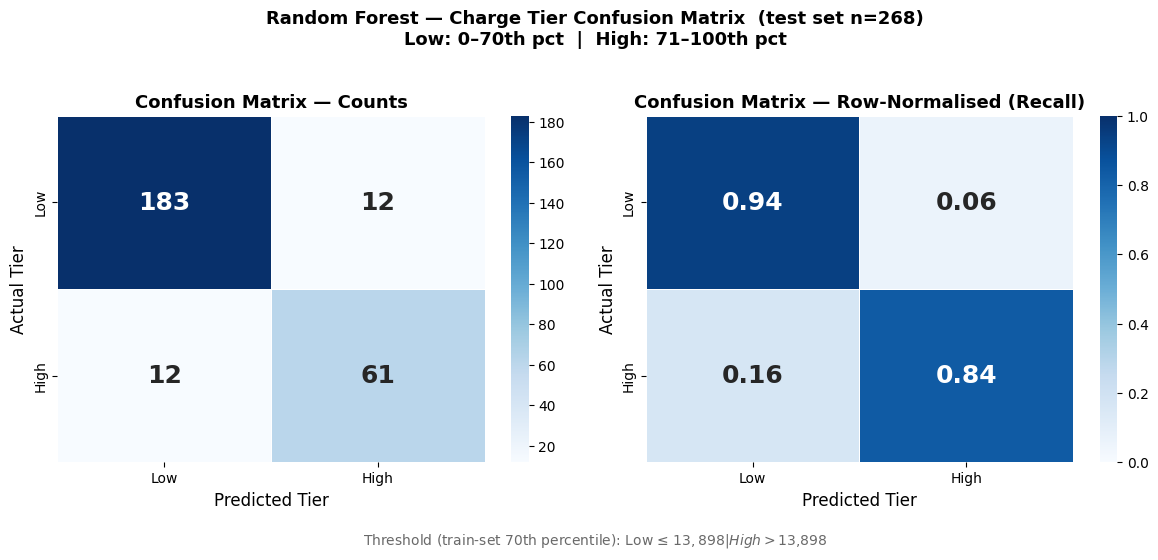

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ── 1. Load & encode ──────────────────────────────────────────────────────────
df = pd.read_csv("insurance.csv")

df_enc = df.copy()
df_enc["sex_bin"]    = (df_enc["sex"] == "female").astype(int)
df_enc["smoker_bin"] = (df_enc["smoker"] == "yes").astype(int)
region_dummies = pd.get_dummies(df_enc["region"], prefix="region", drop_first=True).astype(int)
df_enc = pd.concat([df_enc, region_dummies], axis=1)

FEATURES = ["age", "sex_bin", "bmi", "children", "smoker_bin",
            "region_northwest", "region_southeast", "region_southwest"]

X = df_enc[FEATURES].values
y = df_enc["charges"].values

# ── 2. Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 3. Fit RF on training set ─────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_test = rf.predict(X_test)

# ── 4. Threshold from TRAINING set (avoids leakage) ──────────────────────────
p70 = np.percentile(y_train, 70)
print(f"70th percentile threshold (train set): ${p70:,.2f}")

# ── 5. Assign tiers ───────────────────────────────────────────────────────────
def assign_tier(values, threshold):
    return np.where(values <= threshold, "Low", "High")

actual_tiers = assign_tier(y_test,      p70)
pred_tiers   = assign_tier(y_pred_test, p70)

tier_order = ["Low", "High"]
print(f"\nTier distribution (test set, n={len(y_test)}):")
summary = pd.DataFrame({
    "Actual":    pd.Series(actual_tiers).value_counts().reindex(tier_order),
    "Predicted": pd.Series(pred_tiers).value_counts().reindex(tier_order),
})
print(summary.to_string())

# ── 6. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(actual_tiers, pred_tiers, labels=tier_order)
cm_df = pd.DataFrame(cm, index=[f"Actual {t}" for t in tier_order],
                         columns=[f"Pred {t}" for t in tier_order])
print(f"\nConfusion Matrix (total = {cm.sum()}):")
print(cm_df.to_string())
print("\nClassification Report:")
print(classification_report(actual_tiers, pred_tiers, labels=tier_order))

# ── 7. Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=tier_order, yticklabels=tier_order,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 18, "weight": "bold"}, ax=axes[0])
axes[0].set_xlabel("Predicted Tier", fontsize=12)
axes[0].set_ylabel("Actual Tier", fontsize=12)
axes[0].set_title("Confusion Matrix — Counts", fontsize=13, fontweight="bold")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=tier_order, yticklabels=tier_order,
            linewidths=0.5, linecolor="white", vmin=0, vmax=1,
            annot_kws={"size": 18, "weight": "bold"}, ax=axes[1])
axes[1].set_xlabel("Predicted Tier", fontsize=12)
axes[1].set_ylabel("Actual Tier", fontsize=12)
axes[1].set_title("Confusion Matrix — Row-Normalised (Recall)", fontsize=13, fontweight="bold")

thresh_note = f"Threshold (train-set 70th percentile): Low ≤ ${p70:,.0f}  |  High > ${p70:,.0f}"
fig.text(0.5, -0.04, thresh_note, ha="center", fontsize=10, color="dimgray")

fig.suptitle(
    f"Random Forest — Charge Tier Confusion Matrix  (test set n={len(y_test)})\n"
    f"Low: 0–70th pct  |  High: 71–100th pct",
    fontsize=13, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.show()

70th-percentile threshold (train): $13,897.52
Test set — Low: 195  High: 73
AUC = 0.9179


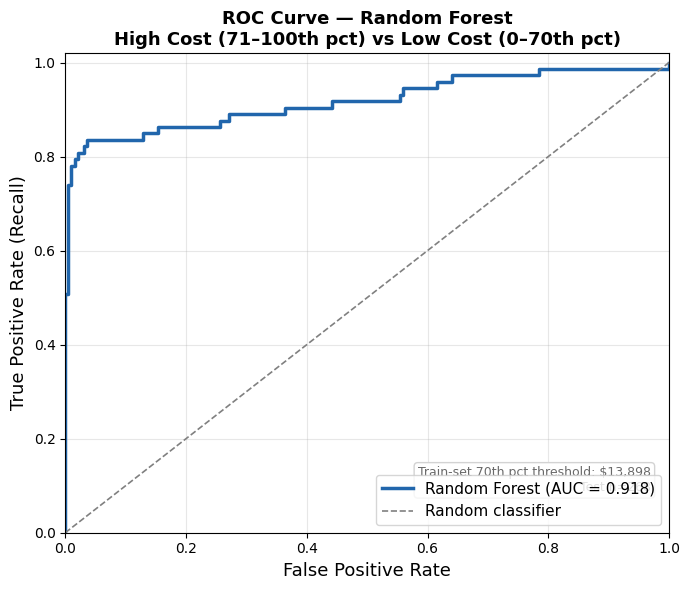

In [191]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

# ── 1. Load & encode ──────────────────────────────────────────────────────────
df = pd.read_csv("insurance.csv")

df_enc = df.copy()
df_enc["sex_bin"]    = (df_enc["sex"] == "female").astype(int)
df_enc["smoker_bin"] = (df_enc["smoker"] == "yes").astype(int)
region_dummies = pd.get_dummies(df_enc["region"], prefix="region", drop_first=True).astype(int)
df_enc = pd.concat([df_enc, region_dummies], axis=1)

FEATURES = ["age", "sex_bin", "bmi", "children", "smoker_bin",
            "region_northwest", "region_southeast", "region_southwest"]

X = df_enc[FEATURES].values
y = df_enc["charges"].values

# ── 2. Train / test split (80/20) ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 3. Fit RF ─────────────────────────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_scores = rf.predict(X_test)          # continuous scores for ROC

# ── 4. Threshold from TRAINING set only (no leakage) ─────────────────────────
p70 = np.percentile(y_train, 70)
print(f"70th-percentile threshold (train): ${p70:,.2f}")

# Binary labels: 1 = High (>p70), 0 = Low
y_true_bin = (y_test > p70).astype(int)
print(f"Test set — Low: {(y_true_bin==0).sum()}  High: {(y_true_bin==1).sum()}")

# ── 5. ROC curve ──────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_true_bin, y_scores, pos_label=1)
roc_auc = auc(fpr, tpr)
print(f"AUC = {roc_auc:.4f}")

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color="#2166ac", lw=2.5,
        label=f"Random Forest (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1.2, linestyle="--", label="Random classifier")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=13)
ax.set_title(
    "ROC Curve — Random Forest\n"
    "High Cost (71–100th pct) vs Low Cost (0–70th pct)",
    fontsize=13, fontweight="bold"
)
ax.legend(loc="lower right", fontsize=11)

# Threshold annotation note
ax.text(0.97, 0.08,
        f"Train-set 70th pct threshold: ${p70:,.0f}\n"
        f"Test n={len(y_test)}",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, color="dimgray",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgrey"))

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
